# Intro Deep Learning

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib

print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 1531552426119195068
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14426112000
locality {
  bus_id: 1
  links {
  }
}
incarnation: 15784763803730298562
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]
2.19.0
Num GPUs Available:  1


# Preprocessing
- One-hot labels
- Reshape and normalize data

In [2]:
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load Data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

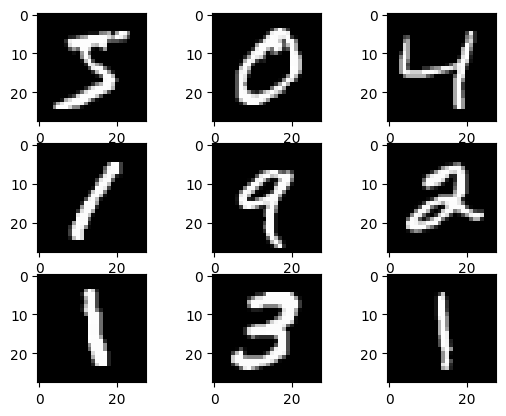

In [4]:
from matplotlib import pyplot
import numpy as np

# create a grid of 3x3 images
for i in range(0, 9):
	pyplot.subplot(330 + 1 + i)
	pyplot.imshow(X_train[i], cmap=pyplot.get_cmap('gray'))
pyplot.show()

In [ ]:
X_train.shape[1]

28

In [5]:
# compute the number of labels
num_labels = len(np.unique(y_train))

# convert to one-hot vector
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# image dimensions (assumed square)
image_size = X_train.shape[1]
input_size = image_size * image_size

# resize and normalize
X_train = np.reshape(X_train, [-1, input_size])
X_train = X_train.astype('float32') / 255
X_test = np.reshape(X_test, [-1, input_size])
X_test = X_test.astype('float32') / 255

In [6]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 784), (10000, 784), (60000, 10), (10000, 10))

# MLP Model

## Hyperparameters

In [7]:
batch_size = 80
hidden_units = 180
dropout = 0.30

In [8]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout


model = Sequential(name="MLP")

# Las capas densas son las fully connectd
model.add(Dense(hidden_units, input_dim=input_size, activation = "relu"))
model.add(Dropout(dropout))

model.add(Dense(hidden_units, activation = "relu"))
model.add(Dropout(dropout))

model.add(Dense(num_labels))
model.add(Activation('softmax')) # Se usa softmax cuando es multiclase, te la la probabilidad de que sea cada clase, el total da 1

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 180)            │       141,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 180)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 180)            │        32,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 180)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,690 (686.29 KB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    x = X_train,
    y = y_train,
    validation_split = .1,
    epochs = 20,
    batch_size=batch_size,
)

Epoch 1/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7955 - loss: 0.6579 - val_accuracy: 0.9658 - val_loss: 0.1105
Epoch 2/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9455 - loss: 0.1806 - val_accuracy: 0.9727 - val_loss: 0.0901
Epoch 3/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9596 - loss: 0.1322 - val_accuracy: 0.9778 - val_loss: 0.0800
Epoch 4/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9661 - loss: 0.1095 - val_accuracy: 0.9793 - val_loss: 0.0734
Epoch 5/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9704 - loss: 0.0962 - val_accuracy: 0.9803 - val_loss: 0.0667
Epoch 6/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9731 - loss: 0.0823 - val_accuracy: 0.9812 - val_loss: 0.0647
Epoch 7/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9752 - loss: 0.0757 - val_accuracy: 0.9790 - val_loss: 0.0719
Epoch 8/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9768 - loss: 0.0696 - val_accuracy: 0.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


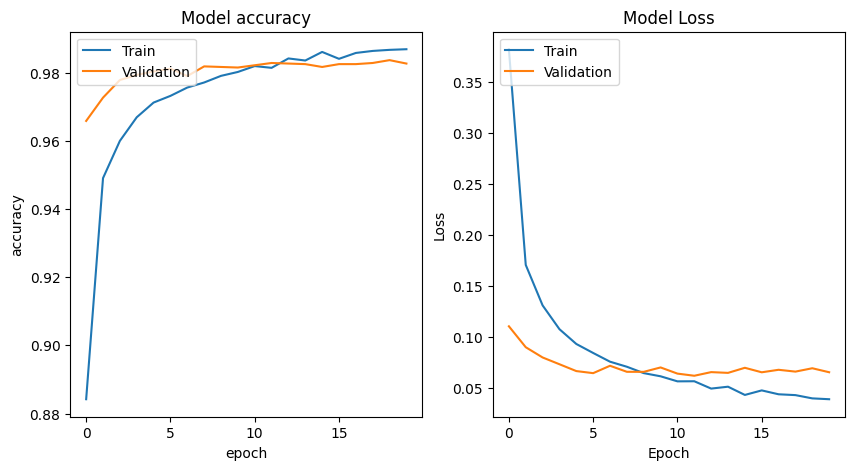

In [11]:
import matplotlib.pyplot as plt

def plot_history(history):

    plt.figure(figsize=(10, 5))

    # summarize history for mean_squared_error
    plt.subplot(121)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # summarize history for loss
    plt.subplot(122)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

print(history.history.keys())
plot_history(history)

## Model Evaluation

In [12]:
_, acc = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)
print("\nTest accuracy: %.1f%%" % (100.0 * acc))


Test accuracy: 98.2%


## Save Model

In [17]:
model.save('MLP_MNIST.h5')

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Model

In [18]:
reconstructed_model = tf.keras.models.load_model("MLP_MNIST.h5")
_, acc = reconstructed_model.evaluate(X_test, y_test)
print("\nTest accuracy: %.1f%%" % (100.0 * acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9782 - loss: 0.0797

Test accuracy: 98.2%


# CNN Model

In [19]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
num_labels = len(np.unique(y_train))
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# image dimensions (assumed square)
image_size = X_train.shape[1]
input_size = image_size * image_size
img_channels = 1

# resize and normalize
X_train = np.reshape(X_train, [-1, image_size, image_size, img_channels])
X_train = X_train.astype('float32') / 255
X_test = np.reshape(X_test, [-1, image_size, image_size, img_channels])
X_test = X_test.astype('float32') / 255


In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape
# 28 = alto y ancho
# 1 = canales

((60000, 28, 28, 1), (10000, 28, 28, 1), (60000, 10), (10000, 10))

## Model

In [21]:
from keras.layers import Conv2D, MaxPooling2D

num_labels = 10
input_size = 28 * 28

model = Sequential(name = "CNN")

model.add(Conv2D(32, kernel_size=3, input_shape=(28, 28, 1), activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# El 64 son los canales
model.add(Conv2D(64, kernel_size=3, activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten()) # Reshape en una sola dimensión
model.add(Dropout(0.5))
model.add(Dense(num_labels, activation = "softmax"))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(
    # train_generator,
    x = X_train,
    y = y_train,
    validation_split = .1,
    epochs = 10,
    verbose = True
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8466 - loss: 0.4900 - val_accuracy: 0.9852 - val_loss: 0.0607
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9728 - loss: 0.0895 - val_accuracy: 0.9875 - val_loss: 0.0448
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9798 - loss: 0.0645 - val_accuracy: 0.9885 - val_loss: 0.0380
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9825 - loss: 0.0530 - val_accuracy: 0.9902 - val_loss: 0.0334
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9848 - loss: 0.0489 - val_accuracy: 0.9907 - val_loss: 0.0338
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9862 - loss: 0.0428 - val_accuracy: 0.9910 - val_loss: 0.0323
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9864 - loss: 0.0406 - val_accuracy: 0.9913 - val_loss: 0.0286
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9872 - loss: 0.0387 

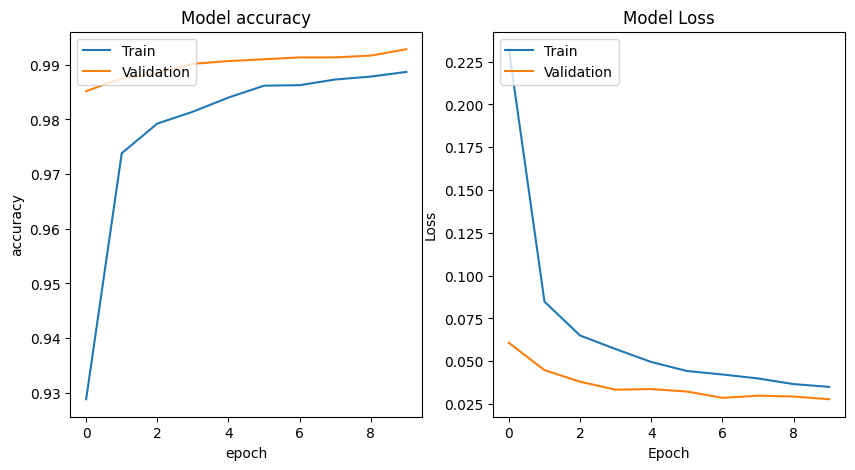

In [23]:
plot_history(history)

In [24]:
_, acc = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print("\nTest accuracy: %.1f%%" % (100.0 * acc))


Test accuracy: 99.2%


# Data Augmentation

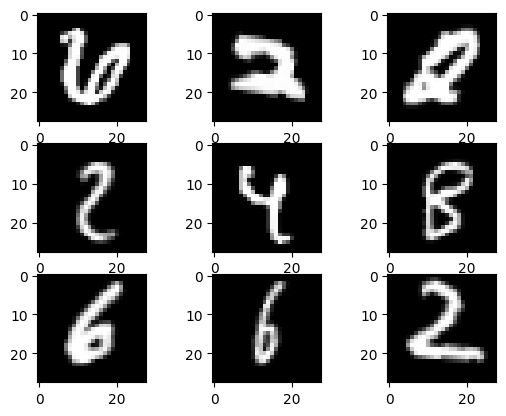

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
	featurewise_center=True,
	featurewise_std_normalization=True,
	rotation_range=10,
	horizontal_flip=False,
	validation_split = 0.1
	# vertical_flip=True
)

# fit parameters from data
datagen.fit(X_train)

# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=9):
	# create a grid of 3x3 images
	for i in range(0, 9):
		pyplot.subplot(330 + 1 + i)
		pyplot.imshow(X_batch[i].reshape(28, 28), cmap=pyplot.get_cmap('gray'))
	# show the plot
	pyplot.show()
	break

In [26]:
datagen.fit(X_train)
train_generator = datagen.flow(X_train, y_train, batch_size=128, subset='training')
validation_generator = datagen.flow(X_train, y_train, batch_size=128, subset='validation')

In [27]:
model = Sequential(name = "CNN_DA")
model.add(Conv2D(32, kernel_size=3, input_shape=(28, 28, 1), activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=3, activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(num_labels, activation = "softmax"))
model.summary()

Model: "CNN_DA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs = 10,
    verbose = True,
    validation_data = validation_generator
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.8010 - loss: 0.6384 - val_accuracy: 0.9743 - val_loss: 0.0911
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9664 - loss: 0.1110 - val_accuracy: 0.9813 - val_loss: 0.0642
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9743 - loss: 0.0855 - val_accuracy: 0.9855 - val_loss: 0.0540
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9766 - loss: 0.0742 - val_accuracy: 0.9872 - val_loss: 0.0470
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9800 - loss: 0.0622 - val_accuracy: 0.9880 - val_loss: 0.0438
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9826 - loss: 0.0530 - val_accuracy: 0.9867 - val_loss: 0.0485
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9831 - loss: 0.0520 - val_accuracy: 0.9888 - val_loss: 0.0384
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9855 - loss: 0.0464 - val_accurac

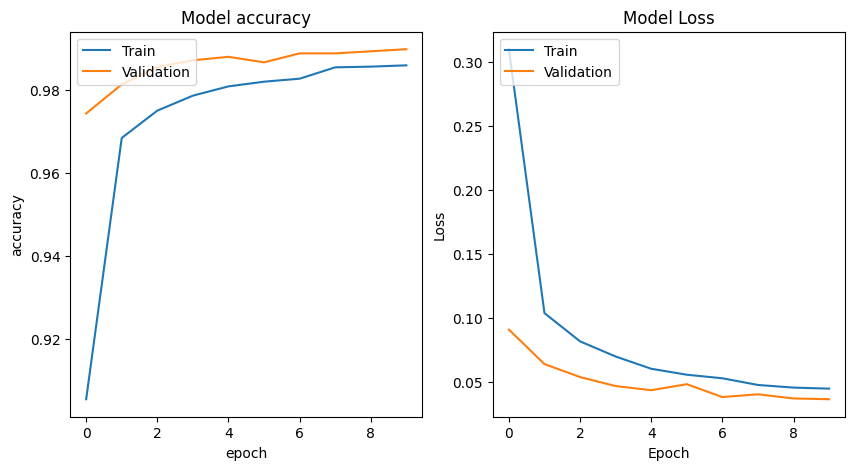

In [29]:
plot_history(history)

In [30]:
_, acc = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print("\nTest accuracy: %.1f%%" % (100.0 * acc))


Test accuracy: 99.1%


# Serializing Model

In [31]:
model.save('CNN_MNIST.h5')

## Load Model

In [32]:
reconstructed_model = tf.keras.models.load_model("CNN_MNIST.h5")

In [33]:
reconstructed_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9896 - loss: 0.2102


[0.19714462757110596, 0.9912999868392944]